# Автоматический подбор музыки для видео

ноутбук запускает весь ML-пайплайн: скачивание подвыборки HarmonySet, подготовка manifest, извлечение признаков, обучение модели, оценка и демо топ-k рекомендаций

### Установка зависимостей

In [1]:
!apt-get -qq update
!apt-get -qq install -y ffmpeg
!pip -q install opencv-python librosa datasets yt-dlp pandas numpy matplotlib scikit-learn tqdm PyYAML

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.3/182.3 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 50.7 MB/s eta 0:00:00


### Подключение проекта

In [3]:
import os
import sys
from pathlib import Path

REPO_URL = 'https://github.com/mpaoloo/music-video-retrieval.git'
PROJECT_DIR = Path('/content/music-video-retrieval')

if REPO_URL and not PROJECT_DIR.exists():
    !git clone {REPO_URL} {PROJECT_DIR}

os.chdir(PROJECT_DIR)
sys.path.append(str(PROJECT_DIR))
print('Директория проекта:', PROJECT_DIR)
print('Файлы:', os.listdir(PROJECT_DIR)[:10])

Cloning into '/content/music-video-retrieval'...
remote: Enumerating objects: 106, done.
remote: Counting objects: 100% (106/106), done.
remote: Compressing objects: 100% (71/71), done.
remote: Total 106 (delta 46), reused 84 (delta 25), pack-reused 0 (from 0)
Receiving objects: 100% (106/106), 29.83 KiB | 2.98 MiB/s, done.
Resolving deltas: 100% (46/46), done.
Директория проекта: /content/music-video-retrieval
Файлы: ['README.md', 'notebooks', 'configs', 'src', '.git', 'requirements.txt', '.vscode', '.gitignore']


In [8]:
!cd /content/music-video-retrieval && git pull

Already up to date.


### Настройки эксперимента

Размер подвыборки исходного датасета

In [5]:
LIMIT = 1500

### Скачивание данных

HarmonySet хранит YouTube ссылки и текстовые аннотации. Сначала скачиваем метаданные и сами видео. Это довольно нестабильная часть проекта, потому что часть роликов может быть удалена или недоступна

In [6]:
!python -m src.data.download_harmonyset --limit {LIMIT}

Загружаем HarmonySet метаданные, limit=1500
HarmonySet_Train.json: 100% 132M/132M [00:02<00:00, 50.1MB/s]
Generating train split: 44470 examples [00:04, 10783.35 examples/s]
Сохраняем начальные метаданные в /content/music-video-retrieval/data/raw/harmonyset_subset.csv (начало загрузки)
[download] Got error: HTTPSConnectionPool(host='rr3---sn-qxoedn7k.googlevideo.com', port=443): Read timed out. (read timeout=20.0)
[download] Got error: HTTPSConnectionPool(host='rr1---sn-qxo7rne7.googlevideo.com', port=443): Read timed out. (read timeout=20.0)
Сохраняем метаданные в /content/music-video-retrieval/data/raw/harmonyset_subset.csv
Downloaded 1243/1500 videos


## 5. Manifest и EDA

Делаем таблицу manifest , в которой лежат только те видео, которые реально скачались и открываются через OpenCV. Здесь же происходит train/val/test split.

In [9]:
!python -m src.data.build_manifest

Saved manifest to /content/music-video-retrieval/data/processed/manifest.csv
split
train    870
test     187
val      186
Average duration: 32.29 seconds


,pair_id,url,video_path,annotation,duration,fps,frames,split
0,6282,https://www.youtube.com/watch?v=K4j0i_y6y1I,/content/music-video-retrieval/data/raw/videos...,Rhythm and Synchronization: The music and vide...,31.966667,30.00000,959,train
1,29495,https://www.youtube.com/watch?v=E_JbmZ_xImw,/content/music-video-retrieval/data/raw/videos...,Rhythm and Synchronization: The music maintain...,20.360000,25.00000,509,train
2,31617,https://www.youtube.com/watch?v=_YYtTxpDLGk,/content/music-video-retrieval/data/raw/videos...,Here's an analysis of the provided video and m...,51.700000,30.00000,1551,train
3,44064,https://www.youtube.com/watch?v=LzUVknU2akk,/content/music-video-retrieval/data/raw/videos...,Rhythm and Synchronization: The video features...,59.466667,30.00000,1784,train
4,33937,https://www.youtube.com/watch?v=xvNZhQnG7Q8,/content/music-video-retrieval/data/raw/videos...,Rhythm and Synchronization: The video features...,14.981633,29.97003,449,train


Всего строк: 1243
split
train    870
test     187
val      186
Name: count, dtype: int64


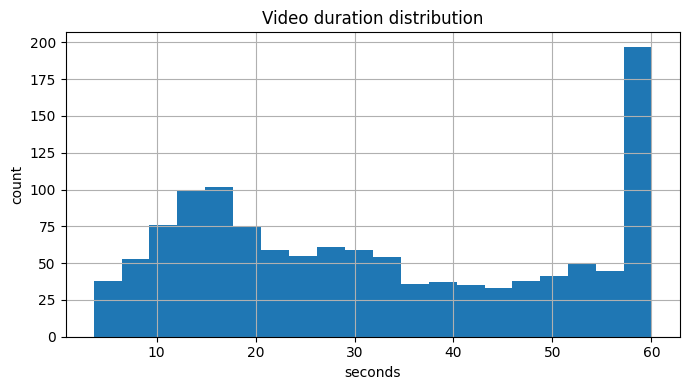

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import os

manifest = pd.read_csv('data/processed/manifest.csv')
display(manifest.head())
print('Всего строк:', len(manifest))
print(manifest['split'].value_counts())

plt.figure(figsize=(7, 4))
manifest['duration'].hist(bins=20)
plt.title('Video duration distribution')
plt.xlabel('seconds')
plt.ylabel('count')

os.makedirs('reports', exist_ok=True)
plt.tight_layout()
plt.savefig('reports/duration_distribution.png', dpi=160)
plt.show()

In [11]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Извлечение признаков

Для видео берём несколько кадров и пропускаем через ResNet50. Для аудио достаём дорожку через ffmpeg и считаем mel спектрограммы

In [ ]:
!python -m src.features.extract_features

Используем девайс: cpu
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100% 97.8M/97.8M [00:01<00:00, 76.7MB/s]
Извлекаем признаки:   9% 118/1243 [11:31<1:49:27,  5.84s/it][mov,mp4,m4a,3gp,3g2,mj2 @ 0x40ba79c0] stream 0, offset 0xc2de: partial file
[mov,mp4,m4a,3gp,3g2,mj2 @ 0x40ba79c0] stream 0, offset 0xd12f: partial file
[mov,mp4,m4a,3gp,3g2,mj2 @ 0x40ba79c0] stream 0, offset 0xc2de: partial file
[mov,mp4,m4a,3gp,3g2,mj2 @ 0x40ba79c0] stream 0, offset 0xd12f: partial file
[mov,mp4,m4a,3gp,3g2,mj2 @ 0x40ba79c0] stream 0, offset 0xc2de: partial file
[mov,mp4,m4a,3gp,3g2,mj2 @ 0x40ba79c0] stream 0, offset 0xc2de: partial file
[mov,mp4,m4a,3gp,3g2,mj2 @ 0x40ba79c0] stream 0, offset 0xc2de: partial file
[mov,mp4,m4a,3gp,3g2,mj2 @ 0x40ba79c0] stream 0, offset 0xc2de: partial file
[mov,mp4,m4a,3gp,3g2,mj2 @ 0x40ba79c0] stream 0, offset 0xc2de: partial file
[mov,mp4,m4a,3gp,3g2,mj2 @ 0x40ba79c0] stream 0, o

In [23]:
features = pd.read_csv('data/processed/features/features.csv')
display(features[['pair_id', 'split', 'video_feature_path', 'audio_feature_path']].head())
print('Feature rows:', len(features))
print(features['split'].value_counts())

,pair_id,split,video_feature_path,audio_feature_path
0,6282,train,/content/music-video-retrieval/data/processed/...,/content/music-video-retrieval/data/processed/...
1,29495,val,/content/music-video-retrieval/data/processed/...,/content/music-video-retrieval/data/processed/...
2,31617,train,/content/music-video-retrieval/data/processed/...,/content/music-video-retrieval/data/processed/...
3,44064,train,/content/music-video-retrieval/data/processed/...,/content/music-video-retrieval/data/processed/...
4,33937,train,/content/music-video-retrieval/data/processed/...,/content/music-video-retrieval/data/processed/...


Feature rows: 419
split
train    293
val       63
test      63
Name: count, dtype: int64


### Обучение модели

Модель обучается так: в каждом batch есть несколько правильных пар video audio. Для каждого видео правильная музыка это аудио с тем же индексом в batch, остальные аудио считаются отрицательными примерами.

In [24]:
!python -m src.train

Epoch 01: loss=3.6019, val_hit@1=0.016, val_hit@5=0.079, val_mrr=0.070
Epoch 02: loss=3.5640, val_hit@1=0.000, val_hit@5=0.095, val_mrr=0.073
Epoch 03: loss=3.5513, val_hit@1=0.016, val_hit@5=0.143, val_mrr=0.082
Epoch 04: loss=3.5581, val_hit@1=0.032, val_hit@5=0.111, val_mrr=0.090
Epoch 05: loss=3.5323, val_hit@1=0.032, val_hit@5=0.063, val_mrr=0.079
Epoch 06: loss=3.5559, val_hit@1=0.016, val_hit@5=0.063, val_mrr=0.070
Epoch 07: loss=3.5489, val_hit@1=0.000, val_hit@5=0.063, val_mrr=0.060
Epoch 08: loss=3.5378, val_hit@1=0.000, val_hit@5=0.095, val_mrr=0.069
Epoch 09: loss=3.5254, val_hit@1=0.000, val_hit@5=0.079, val_mrr=0.066
Epoch 10: loss=3.5220, val_hit@1=0.000, val_hit@5=0.095, val_mrr=0.068
Epoch 11: loss=3.5266, val_hit@1=0.000, val_hit@5=0.095, val_mrr=0.069
Epoch 12: loss=3.4668, val_hit@1=0.016, val_hit@5=0.127, val_mrr=0.088
Epoch 13: loss=3.4834, val_hit@1=0.016, val_hit@5=0.079, val_mrr=0.076
Epoch 14: loss=3.3834, val_hit@1=0.000, val_hit@5=0.079, val_mrr=0.066
Epoch 

,epoch,train_loss,val_hit_at_1,val_hit_at_5,val_mrr
25,26,2.685632,0.000000,0.079365,0.066911
26,27,2.740562,0.015873,0.095238,0.087300
27,28,2.663295,0.031746,0.142857,0.103684
28,29,2.675363,0.000000,0.126984,0.073791
29,30,2.671939,0.000000,0.079365,0.076345


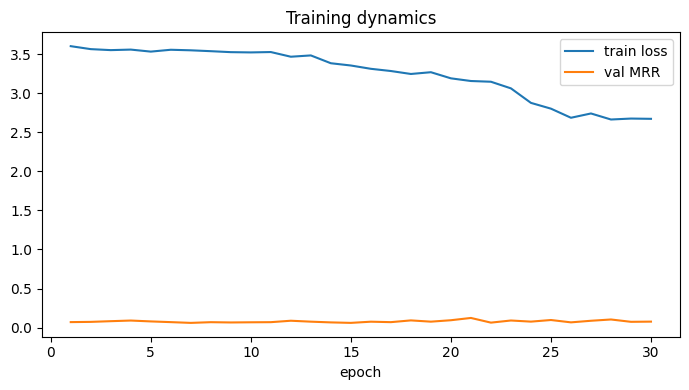

In [25]:
history = pd.read_csv('reports/training_history.csv')
display(history.tail())

plt.figure(figsize=(7, 4))
plt.plot(history['epoch'], history['train_loss'], label='train loss')
plt.plot(history['epoch'], history['val_mrr'], label='val MRR')
plt.legend()
plt.title('Training dynamics')
plt.xlabel('epoch')
plt.tight_layout()
plt.show()

### Оценка качества

Главные метрики: `Hit@1`, `Hit@5`, `MRR`. Также считаем random baseline, чтобы было понятно, лучше ли модель рандомного выбора аудио

In [13]:
!python -m src.evaluate --split test

Evaluation split: test
           name  hit_at_1  hit_at_5      mrr  mean_rank  num_queries  num_candidates  effective_top_k
          model  0.015873  0.142857 0.090505  30.904762         63.0            63.0                5
random_baseline  0.015873  0.079365 0.075052        NaN          NaN             NaN                5
Saved metrics to /content/music-video-retrieval/reports/metrics_test.csv


,name,hit_at_1,hit_at_5,mrr,mean_rank,num_queries,num_candidates,effective_top_k
0,model,0.015873,0.142857,0.090505,30.904762,63.0,63.0,5
1,random_baseline,0.015873,0.079365,0.075052,NaN,NaN,NaN,5


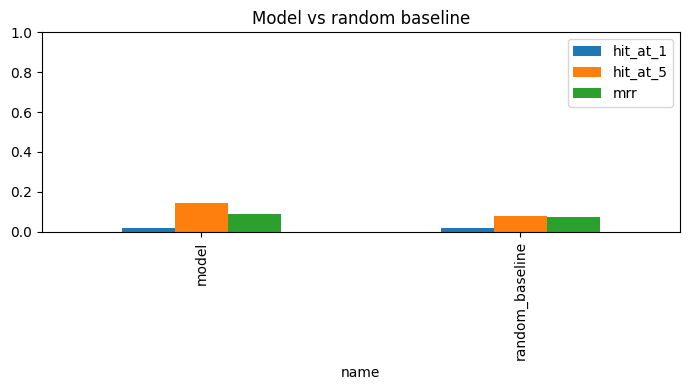

In [14]:
metrics = pd.read_csv('reports/metrics_test.csv')
display(metrics)

metrics.set_index('name')[['hit_at_1', 'hit_at_5', 'mrr']].plot(kind='bar', figsize=(7, 4))
plt.ylim(0, 1)
plt.title('Model vs random baseline')
plt.tight_layout()
plt.show()

### Демо: top-k рекомендаций

Здесь берём одно видео из test split и выводим топ-k аудиодорожек из базы. Если рядом с одной строкой написано `верный pair_id`, значит модель поставила исходную музыку этого видео в топ-k

In [ ]:
!python -m src.infer --split test --row-index 0 --top-k 10